# Kalshi Fed funds rate contracts

Market-implied fed funds target (upper bound) after each FOMC meeting, built from Kalshi's `KXFED` series (including the legacy `FED-*` events).

Each meeting is an event with a ladder of binary contracts: *"Will the upper bound of the federal funds rate be above X% following the meeting?"* A contract's price is the market's P(rate > X). Differencing across the ladder gives a probability for each 25bp outcome, and the expected upper bound is the probability-weighted sum.

**Running it.** Run all cells. The first run downloads everything from Kalshi's public API (no key needed, about 3 minutes) and caches it in `data/`. Later runs read the cache unless you set `REFRESH = True`. It works locally, in JupyterLab, VS Code, or Colab.

API reference: https://docs.kalshi.com/openapi.yaml

In [1]:
# Colab and most Jupyter installs already have these; uncomment if not.
# %pip install pandas matplotlib

import json, os, ssl, time, urllib.error, urllib.parse, urllib.request
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REFRESH = False        # True: re-download from Kalshi even if data/ exists
INTERVAL = 1440        # candle size in minutes: 1, 60 or 1440 (daily)
SERIES = "KXFED"
BASE = "https://api.elections.kalshi.com/trade-api/v2"
DATA = Path("data"); DATA.mkdir(exist_ok=True)
STEP = 0.25            # FOMC moves in 25bp increments

## 1. Download markets and daily candlesticks

Markets that settled before Kalshi's historical cutoff are only served by the `/historical/...` endpoints, so both live and historical endpoints are queried. Historical candles use bare field names (`close`, `volume`) where live ones use `close_dollars`, `volume_fp`.

In [2]:
# python.org builds on macOS ship without CA certs; fall back to the system bundle.
try:
    import certifi
    SSL_CTX = ssl.create_default_context(cafile=certifi.where())
except ImportError:
    SSL_CTX = ssl.create_default_context(
        cafile="/etc/ssl/cert.pem" if os.path.exists("/etc/ssl/cert.pem") else None)


def get(path, params=None, retries=5):
    url = f"{BASE}{path}" + ("?" + urllib.parse.urlencode(params) if params else "")
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=30, context=SSL_CTX) as r:
                time.sleep(0.08)  # stay well under the public rate limit
                return json.load(r)
        except urllib.error.HTTPError as e:
            if e.code == 404:
                return None
            if e.code == 429 or e.code >= 500:
                time.sleep(2 ** attempt); continue
            raise
        except urllib.error.URLError:
            time.sleep(2 ** attempt)
    raise RuntimeError(f"failed: {url}")


def paginate(path, key, params):
    out, cursor = [], None
    while True:
        d = get(path, dict(params, limit=200, **({"cursor": cursor} if cursor else {}))) or {}
        out += d.get(key, [])
        cursor = d.get("cursor")
        if not cursor:
            return out


to_ts = lambda iso: int(datetime.fromisoformat(iso.replace("Z", "+00:00")).timestamp())
num = lambda x: None if x in (None, "") else float(x)
ohlc = lambda d, f: num((d or {}).get(f"{f}_dollars", (d or {}).get(f)))


def fetch_candles(m, historical):
    start, end = to_ts(m["open_time"]), to_ts(m["close_time"]) + 86400
    path = (f"/historical/markets/{m['ticker']}/candlesticks" if historical
            else f"/series/{SERIES}/markets/{m['ticker']}/candlesticks")
    rows, chunk = [], 5000 * INTERVAL * 60 // 2
    for s in range(start, end, chunk):
        d = get(path, {"start_ts": s, "end_ts": min(s + chunk, end), "period_interval": INTERVAL})
        for c in (d or {}).get("candlesticks", []):
            rows.append({"ticker": m["ticker"], "ts": c["end_period_ts"],
                         "yes_bid": ohlc(c.get("yes_bid"), "close"),
                         "yes_ask": ohlc(c.get("yes_ask"), "close"),
                         "last": ohlc(c.get("price"), "close"),
                         "volume": num(c.get("volume_fp", c.get("volume"))),
                         "open_interest": num(c.get("open_interest_fp", c.get("open_interest")))})
    return rows


def download():
    events = paginate("/events", "events", {"series_ticker": SERIES})
    print(f"{len(events)} events in {SERIES}")
    mrows, crows = [], []
    for e in sorted(events, key=lambda e: e["event_ticker"]):
        et = e["event_ticker"]
        live = paginate("/markets", "markets", {"event_ticker": et})
        hist = paginate("/historical/markets", "markets", {"event_ticker": et})
        for historical, ms in ((False, live), (True, hist)):
            for m in ms:
                strike = m.get("floor_strike")
                if strike is None:  # oldest markets: parse from ticker "...-T0.25"
                    strike = float(m["ticker"].rsplit("-T", 1)[-1])
                mrows.append({"ticker": m["ticker"], "event_ticker": et, "event_title": e["title"],
                              "meeting_date": m["close_time"][:10], "strike": float(strike),
                              "status": m["status"], "result": m.get("result"),
                              "open_time": m["open_time"], "close_time": m["close_time"],
                              "volume": num(m.get("volume_fp")), "historical": historical,
                              "title": m.get("title")})
                crows += fetch_candles(m, historical)
        print(f"  {et}: {len(live)} live + {len(hist)} historical markets")
    markets = pd.DataFrame(mrows).sort_values(["meeting_date", "strike"])
    candles = pd.DataFrame(crows)
    candles["datetime"] = pd.to_datetime(candles.ts, unit="s", utc=True)
    # Daily candles end at midnight ET; label each by the ET day it covers.
    candles["date"] = (pd.to_datetime(candles.ts - 1, unit="s", utc=True)
                       .dt.tz_convert("America/New_York").dt.date.astype(str)
                       if INTERVAL == 1440 else candles.datetime.astype(str))
    candles = candles.merge(markets[["ticker", "event_ticker", "strike"]], on="ticker") \
                     .sort_values(["event_ticker", "strike", "ts"])
    markets.to_csv(DATA / "markets.csv", index=False)
    candles.to_csv(DATA / "candles_daily.csv", index=False)
    return markets, candles


if REFRESH or not (DATA / "candles_daily.csv").exists():
    markets, candles = download()
else:
    markets = pd.read_csv(DATA / "markets.csv")
    candles = pd.read_csv(DATA / "candles_daily.csv")
print(f"{markets.event_ticker.nunique()} meetings, {len(markets)} contracts, "
      f"{len(candles):,} candles, through {candles.date.max()}")

52 meetings, 660 contracts, 97,888 candles, through 2026-09-27


## 2. From contract prices to an implied rate

For each contract on each day:

- **Price.** Bid/ask midpoint when the spread is 20¢ or less. Up to 40¢, the last trade clipped into the quote. Wider than that, the strike is dropped for the day.
- **Quiet days.** Kalshi only emits a candle when something changes, so each contract's last quote is carried forward.
- **Monotonicity.** P(rate > k) must fall as k rises. A weighted isotonic fit (tighter quotes weigh more) enforces that without letting one stale print drag the whole ladder.
- **Reliability.** A meeting-day is flagged unreliable when more than 10% of probability sits beyond the usable strikes (as in 2022, when hikes outran the ladder) or in gaps wider than 50bp between them.

In [3]:
def daily_grid(candles, markets):
    close = markets.set_index("ticker").meeting_date
    asof, cols, out = candles.date.max(), ["yes_bid", "yes_ask", "last", "open_interest", "event_ticker", "strike"], []
    for t, g in candles.groupby("ticker"):
        g = g.drop_duplicates("date", keep="last").set_index("date")
        days = pd.date_range(g.index.min(), max(g.index.max(), min(close[t], asof)))
        g = g.reindex(days.strftime("%Y-%m-%d"))
        g[cols] = g[cols].ffill()
        g["volume"] = g.volume.fillna(0)
        g["ticker"] = t
        out.append(g.rename_axis("date").reset_index())
    return pd.concat(out)


def pava_decreasing(y, w):
    # Weighted isotonic regression: best non-increasing fit to y.
    blocks = []
    for yi, wi in zip(y, w):
        blocks.append([yi, wi, 1])
        while len(blocks) > 1 and blocks[-2][0] < blocks[-1][0]:
            v2, w2, n2 = blocks.pop(); v1, w1, n1 = blocks.pop()
            blocks.append([(v1 * w1 + v2 * w2) / (w1 + w2), w1 + w2, n1 + n2])
    return [v for v, _, n in blocks for _ in range(n)]


def implied(candles, markets):
    df = daily_grid(candles, markets).merge(markets[["ticker", "meeting_date"]], on="ticker")
    df = df[df.date <= df.meeting_date]
    spread = df.yes_ask - df.yes_bid
    mid = (df.yes_bid + df.yes_ask) / 2
    last = df["last"].clip(lower=df.yes_bid, upper=df.yes_ask)
    df["p_above"] = mid.where(spread.between(0, 0.20), last.where(spread.between(0, 0.40)))
    df["w"] = 1 / (spread.clip(lower=0).fillna(1) + 0.02)
    df = df.dropna(subset=["p_above"])

    out = []
    for (ev, date), g in df.groupby(["event_ticker", "date"]):
        g = g.sort_values("strike")
        k = g.strike.to_numpy()
        p = np.clip(pava_decreasing(g.p_above.to_numpy(), g.w.to_numpy()), 0, 1)
        # Buckets: <=k0, (k0,k1], ..., >k_last. A bucket spanning several 25bp
        # outcomes (a strike was missing that day) is valued at its midpoint.
        probs = {f"p_le_{k[0]:.2f}": 1 - p[0]}
        mean, wide = k[0] * (1 - p[0]), 0.0
        for i in range(len(k)):
            hi = p[i + 1] if i + 1 < len(k) else 0.0
            top = k[i + 1] if i + 1 < len(k) else k[i] + STEP
            mass = p[i] - hi
            probs[f"p_{top:.2f}"] = mass
            mean += (k[i] + STEP + top) / 2 * mass
            wide += mass if top - k[i] > 2 * STEP else 0
        lo_tail = 0.0 if k[0] <= 0.25 else 1 - p[0]   # below 0.25% is the zero lower bound
        hi_tail = p[-1]
        out.append({"event_ticker": ev, "meeting_date": g.meeting_date.iloc[0], "date": date,
                    "implied_upper_bound": round(mean, 4),
                    "most_likely": max(probs, key=probs.get).split("_")[-1],
                    "n_strikes": len(k), "tail_mass": round(lo_tail + hi_tail, 4),
                    "gap_mass": round(wide, 4),
                    "reliable": bool(lo_tail <= 0.10 and hi_tail <= 0.10 and wide <= 0.10),
                    "volume": g.volume.sum(), "open_interest": g.open_interest.sum(),
                    "distribution": json.dumps({a: round(b, 4) for a, b in probs.items()})})
    return pd.DataFrame(out).sort_values(["meeting_date", "date"])


rates = implied(candles, markets)
rates.to_csv(DATA / "implied_rate_daily.csv", index=False)
print(f"{len(rates):,} meeting-days, {rates.reliable.sum():,} reliable")
rates.tail()

12,916 meeting-days, 8,155 reliable


,event_ticker,meeting_date,date,implied_upper_bound,most_likely,n_strikes,tail_mass,gap_mass,reliable,volume,open_interest,distribution
12911,KXFED-28JAN,2028-01-26,2026-09-23,3.2742,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.03, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12912,KXFED-28JAN,2028-01-26,2026-09-24,3.3450,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12913,KXFED-28JAN,2028-01-26,2026-09-25,3.3675,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12914,KXFED-28JAN,2028-01-26,2026-09-26,3.3675,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12915,KXFED-28JAN,2028-01-26,2026-09-27,3.3675,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."


## 3. Realized decisions, scorecard, and constant-horizon series

The realized upper bound comes from how each ladder settled. The scorecard compares it with the implied rate on the last day before the meeting. The constant-horizon series tracks, each day, the implied rate for the next, 3rd and 6th upcoming meeting (reliable days only).

In [4]:
settled = markets[markets.result.isin(["yes", "no"])]
realized = (settled.groupby(["event_ticker", "meeting_date"])
            .apply(lambda g: g[g.result == "yes"].strike.max() + STEP if (g.result == "yes").any()
                   else g.strike.min(), include_groups=False)
            .rename("upper_bound").reset_index().sort_values("meeting_date"))

pre = rates[rates.date < rates.meeting_date].groupby("event_ticker").tail(1)
scorecard = (pre[["event_ticker", "meeting_date", "date", "implied_upper_bound"]]
             .merge(realized[["event_ticker", "upper_bound"]], on="event_ticker")
             .rename(columns={"date": "last_quote_date", "upper_bound": "realized"})
             .sort_values("meeting_date"))
scorecard["change_bp"] = (scorecard.realized.diff() * 100).round()
scorecard["error_bp"] = ((scorecard.implied_upper_bound - scorecard.realized) * 100).round(1)

meeting_dates = sorted(rates.meeting_date.unique())
lookup = rates[rates.reliable].set_index(["meeting_date", "date"]).implied_upper_bound
rows = []
for d in sorted(rates.date.unique()):
    upcoming = [x for x in meeting_dates if x >= d]
    past = realized[realized.meeting_date < d]
    row = {"date": d, "current_target": past.upper_bound.iloc[-1] if len(past) else np.nan}
    for name, i in (("next", 0), ("third", 2), ("sixth", 5)):
        mt = upcoming[i] if i < len(upcoming) else None
        row[f"{name}_meeting"] = mt
        row[f"{name}_implied"] = lookup.get((mt, d), np.nan) if mt else np.nan
    rows.append(row)
horizon = pd.DataFrame(rows)
horizon["date"] = pd.to_datetime(horizon.date)

realized.to_csv(DATA / "realized_target.csv", index=False)
scorecard.to_csv(DATA / "meeting_summary.csv", index=False)
horizon.to_csv(DATA / "constant_horizon.csv", index=False)

err = scorecard.error_bp.abs()
print(f"Day-before implied vs realized, {len(scorecard)} meetings: "
      f"median |error| {err.median():.1f}bp, mean {err.mean():.1f}bp, max {err.max():.1f}bp")

Day-before implied vs realized, 41 meetings: median |error| 0.6bp, mean 1.3bp, max 10.5bp


## 4. Where things stand today

In [5]:
asof = rates.date.max()
target = realized[realized.meeting_date <= asof].iloc[-1]
nxt = rates[(rates.meeting_date >= asof) & (rates.date == asof)].iloc[0]
dist = json.loads(nxt.distribution)
T = target.upper_bound
val = lambda key: float(key.split("_")[-1])
hike = sum(v for k, v in dist.items() if val(k) > T + 1e-9)
cut = sum(v for k, v in dist.items() if val(k) < T - 1e-9)
print(f"As of {asof}")
print(f"  Target upper bound: {T:.2f}% (set {target.meeting_date})")
print(f"  Next meeting {nxt.meeting_date}: implied {nxt.implied_upper_bound:.3f}%  "
      f"| hike {hike:.0%}  hold {1 - hike - cut:.0%}  cut {cut:.0%}")

As of 2026-09-27
  Target upper bound: 4.00% (set 2026-09-16)
  Next meeting 2026-10-28: implied 4.164%  | hike 64%  hold 35%  cut 1%


In [6]:
# Shared chart style: thin lines, recessive grid, colorblind-validated palette.
C = {"s1": "#2a78d6", "s2": "#eb6834", "s3": "#1baf7a", "ink": "#11151c", "ink2": "#4a5160", "grid": "#e3e6ec"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (11, 4.6), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": C["grid"], "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": C["grid"], "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.labelcolor": C["ink2"], "xtick.color": C["ink2"], "ytick.color": C["ink2"],
    "ytick.left": False, "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2,
})
pct = plt.FuncFormatter(lambda v, _: f"{v:.2f}%")

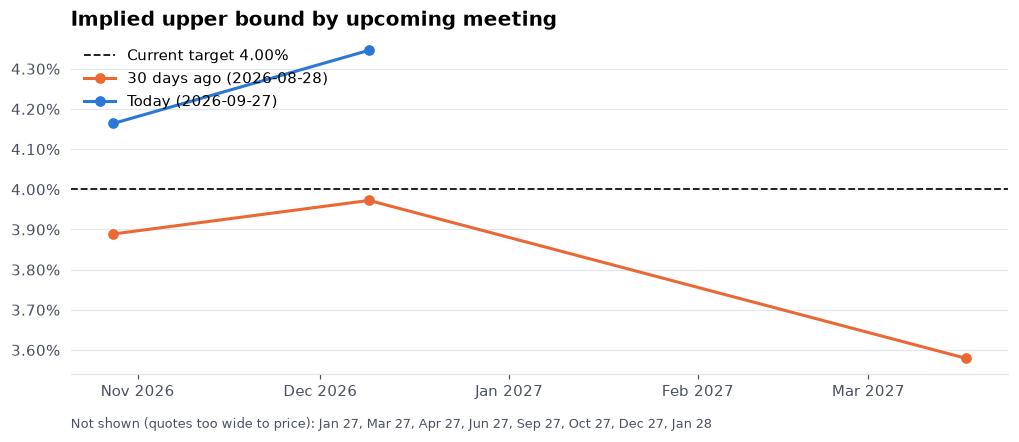

In [7]:
def path_on(date):
    d = rates[(rates.meeting_date >= asof) & (rates.date == date) & rates.reliable]
    return pd.to_datetime(d.meeting_date), d.implied_upper_bound

month_ago = (pd.Timestamp(asof) - timedelta(days=30)).strftime("%Y-%m-%d")
fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(T, color=C["ink"], lw=1.2, ls="--", label=f"Current target {T:.2f}%")
ax.plot(*path_on(month_ago), marker="o", color=C["s2"], label=f"30 days ago ({month_ago})")  # lines join priced meetings only
ax.plot(*path_on(asof), marker="o", color=C["s1"], label=f"Today ({asof})")
ax.yaxis.set_major_formatter(pct)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title("Implied upper bound by upcoming meeting")
ax.legend(loc="upper left")
skipped = rates[(rates.meeting_date >= asof) & (rates.date == asof) & ~rates.reliable].meeting_date
if len(skipped):
    ax.annotate("Not shown (quotes too wide to price): " + ", ".join(pd.to_datetime(skipped).dt.strftime("%b %y")),
                (0, -0.16), xycoords="axes fraction", fontsize=8.5, color=C["ink2"])
plt.show()

## 5. Expectations versus the actual target, 2021 to today

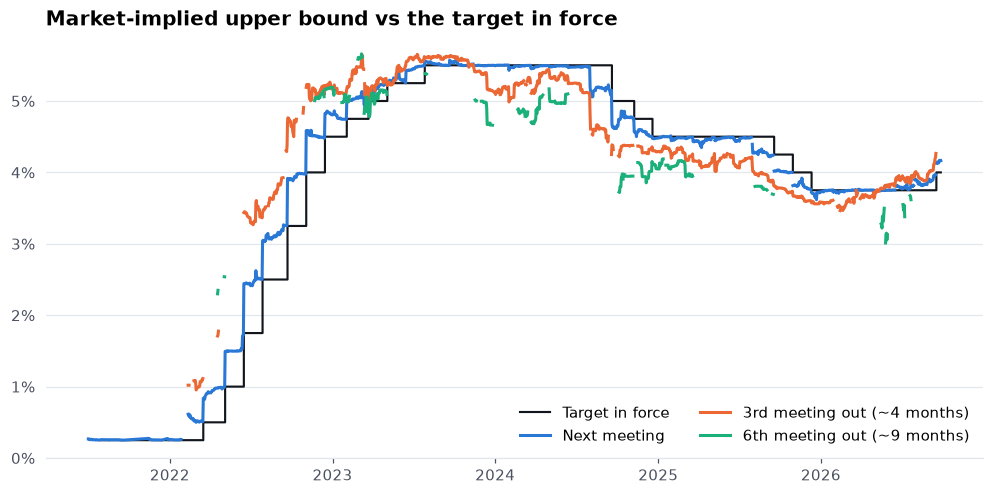

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.step(horizon.date, horizon.current_target, where="post", color=C["ink"], lw=1.4, label="Target in force")
ax.plot(horizon.date, horizon.next_implied, color=C["s1"], label="Next meeting")
ax.plot(horizon.date, horizon.third_implied, color=C["s2"], label="3rd meeting out (~4 months)")
ax.plot(horizon.date, horizon.sixth_implied, color=C["s3"], label="6th meeting out (~9 months)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylim(bottom=0)
ax.set_title("Market-implied upper bound vs the target in force")
ax.legend(loc="lower right", ncol=2)
plt.show()

## 6. Meeting explorer

Set `MEETING` to any event ticker (see the list printed below) and re-run the cell. The top panel is the implied rate over the ladder's life: solid blue where the ladder prices the full distribution, faint gray dashes on unreliable days. The bottom panel is the probability of each 25bp outcome, computed from reliable days only. Outcomes that never reach 10% are folded into the nearest shown bucket.

Meetings: FED-21JUL FED-21SEP FED-21DEC FED-22JAN FED-22MAR FED-22MAY FED-22JUN FED-22JUL FED-22SEP FED-22NOV FED-22DEC FED-23FEB FED-23MAR FED-23MAY FED-23JUN FED-23JUL FED-23SEP FED-23NOV FED-23DEC FED-24JAN FED-24MAR FED-24MAY FED-24JUN FED-24JUL FED-24SEP FED-24NOV FED-24DEC FED-25JAN FED-25MAR FED-25MAY FED-25JUN FED-25JUL FED-25SEP FED-25OCT FED-25DEC KXFED-26JAN KXFED-26MAR KXFED-26APR KXFED-26JUN KXFED-26JUL KXFED-26SEP KXFED-26OCT KXFED-26DEC KXFED-27JAN KXFED-27MAR KXFED-27APR KXFED-27JUN KXFED-27SEP KXFED-27OCT KXFED-27DEC KXFED-28JAN


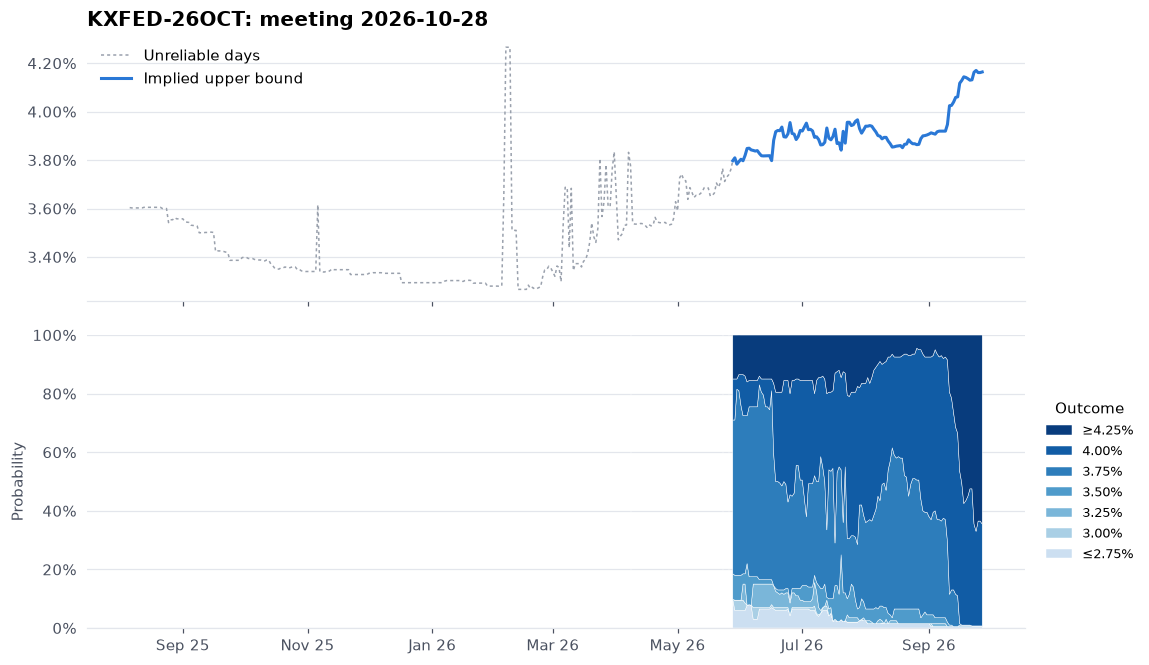

In [9]:
def on_grid(d):
    # Spread each bucket's mass evenly over the 25bp outcomes it spans, so days
    # with missing strikes share one set of outcomes.
    out, prev = {}, None
    for k, v in d.items():
        x = float(k.split("_")[-1])
        pts = [x] if k.startswith("p_le") else [round(prev + STEP * (i + 1), 2) for i in range(max(1, round((x - prev) / STEP)))]
        for q in pts:
            out[q] = out.get(q, 0) + v / len(pts)
        prev = x
    return out


def explore(meeting):
    g = rates[rates.event_ticker == meeting].copy()
    g["dt"] = pd.to_datetime(g.date)
    grid = pd.DataFrame([on_grid(json.loads(x)) for x in g.distribution], index=g.dt).fillna(0)
    grid = grid[sorted(grid.columns)]
    grid[~g.reliable.to_numpy()] = np.nan   # don't draw distributions we can't trust
    keep = [c for c in grid.columns if grid[c].max() >= 0.10] or list(grid.columns)
    lo, hi = grid.columns.get_loc(keep[0]), grid.columns.get_loc(keep[-1])
    shown = grid.iloc[:, lo:hi + 1].copy()
    shown.iloc[:, 0] += grid.iloc[:, :lo].sum(axis=1)
    shown.iloc[:, -1] += grid.iloc[:, hi + 1:].sum(axis=1)
    # The lowest bucket always holds "at or below", the highest "at or above".
    labels = [("≤" if i == 0 else "≥" if i == len(shown.columns) - 1 else "") + f"{c:.2f}%"
              for i, c in enumerate(shown.columns)]

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1.1], "hspace": 0.12})
    a1.plot(g.dt, g.implied_upper_bound, color="#9aa1ad", lw=1, ls=(0, (2, 2)), label="Unreliable days")
    a1.plot(g.dt, g.implied_upper_bound.where(g.reliable), color=C["s1"], label="Implied upper bound")
    r = realized[realized.event_ticker == meeting]
    if len(r):
        a1.axhline(r.upper_bound.iloc[0], color=C["ink"], lw=1.2, ls="--", label=f"Realized {r.upper_bound.iloc[0]:.2f}%")
    a1.yaxis.set_major_formatter(pct)
    a1.legend(loc="upper left")
    a1.set_title(f"{meeting}: meeting {g.meeting_date.iloc[0]}")

    colors = plt.cm.Blues(np.linspace(0.22, 0.95, len(labels)))
    a2.stackplot(shown.index, shown.T.to_numpy(), colors=colors, labels=labels, edgecolor="white", linewidth=0.3)
    a2.set_ylim(0, 1); a2.set_ylabel("Probability")
    a2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    h, l = a2.get_legend_handles_labels()
    a2.legend(h[::-1], l[::-1], loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5, title="Outcome")
    a2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.show()


print("Meetings:", " ".join(sorted(rates.event_ticker.unique(), key=lambda e: rates[rates.event_ticker == e].meeting_date.iloc[0])))
MEETING = nxt.event_ticker   # e.g. "FED-22NOV", "FED-24SEP", "KXFED-26DEC"
explore(MEETING)

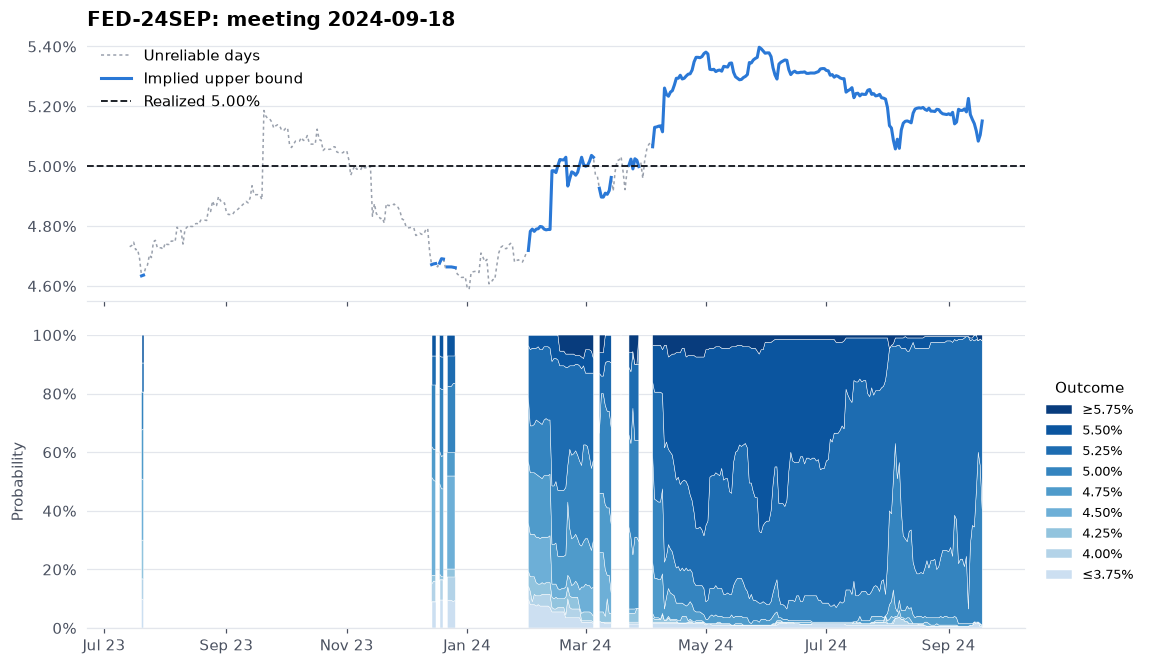

In [10]:
explore("FED-24SEP")   # the 50bp cut in Sep 2024: watch the market swing between 25bp and 50bp

## 7. Scorecard: implied rate the day before each meeting vs the decision

In [11]:
(scorecard.sort_values("meeting_date", ascending=False)
 .style.format({"implied_upper_bound": "{:.3f}%", "realized": "{:.2f}%",
                "change_bp": lambda v: "–" if pd.isna(v) else ("hold" if v == 0 else f"{v:+.0f}bp"),
                "error_bp": "{:+.1f}"})
 .hide(axis="index"))

event_ticker,meeting_date,last_quote_date,implied_upper_bound,realized,change_bp,error_bp
KXFED-26SEP,2026-09-16,2026-09-15,3.969%,4.00%,+25bp,-3.1
KXFED-26JUL,2026-07-29,2026-07-28,3.816%,3.75%,hold,+6.6
KXFED-26JUN,2026-06-17,2026-06-16,3.754%,3.75%,hold,+0.4
KXFED-26APR,2026-04-29,2026-04-28,3.754%,3.75%,hold,+0.4
KXFED-26MAR,2026-03-18,2026-03-17,3.754%,3.75%,hold,+0.4
KXFED-26JAN,2026-01-28,2026-01-27,3.754%,3.75%,hold,+0.4
FED-25DEC,2025-12-10,2025-12-09,3.761%,3.75%,-25bp,+1.1
FED-25OCT,2025-10-29,2025-10-28,4.001%,4.00%,-25bp,+0.1
FED-25SEP,2025-09-17,2025-09-16,4.241%,4.25%,-25bp,-0.9
FED-25JUL,2025-07-30,2025-07-29,4.491%,4.50%,hold,-0.9


## 8. Outputs

All written to `data/`:

| File | Contents |
|---|---|
| `implied_rate_daily.csv` | One row per meeting per day: implied upper bound, outcome distribution, `reliable` flag |
| `constant_horizon.csv` | Per day: implied rate for the next, 3rd and 6th meeting, plus the target in force |
| `candles_daily.csv` | Raw daily bid, ask, last, volume and open interest per contract |
| `markets.csv` | One row per contract with its settlement result |
| `meeting_summary.csv` | The scorecard above |
| `realized_target.csv` | Upper bound after each settled meeting |